Saving input_image.jpeg to input_image.jpeg
Image loaded successfully!
Image Size: (1542, 1085, 3)
Saved: separated_slips/slip_1.jpg
Saved: separated_slips/slip_2.jpg
Saved: separated_slips/slip_3.jpg
Saved: separated_slips/slip_4.jpg
Saved: separated_slips/slip_5.jpg


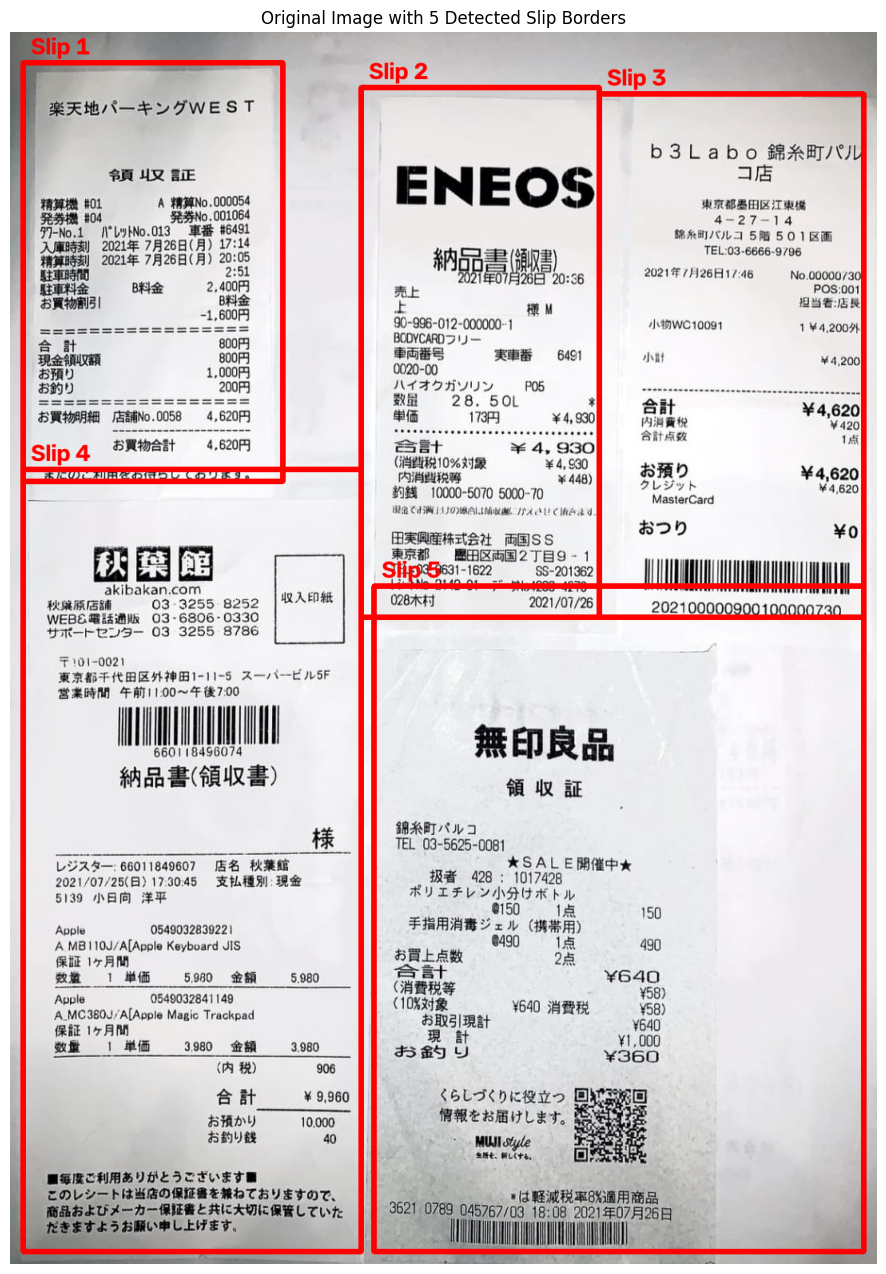

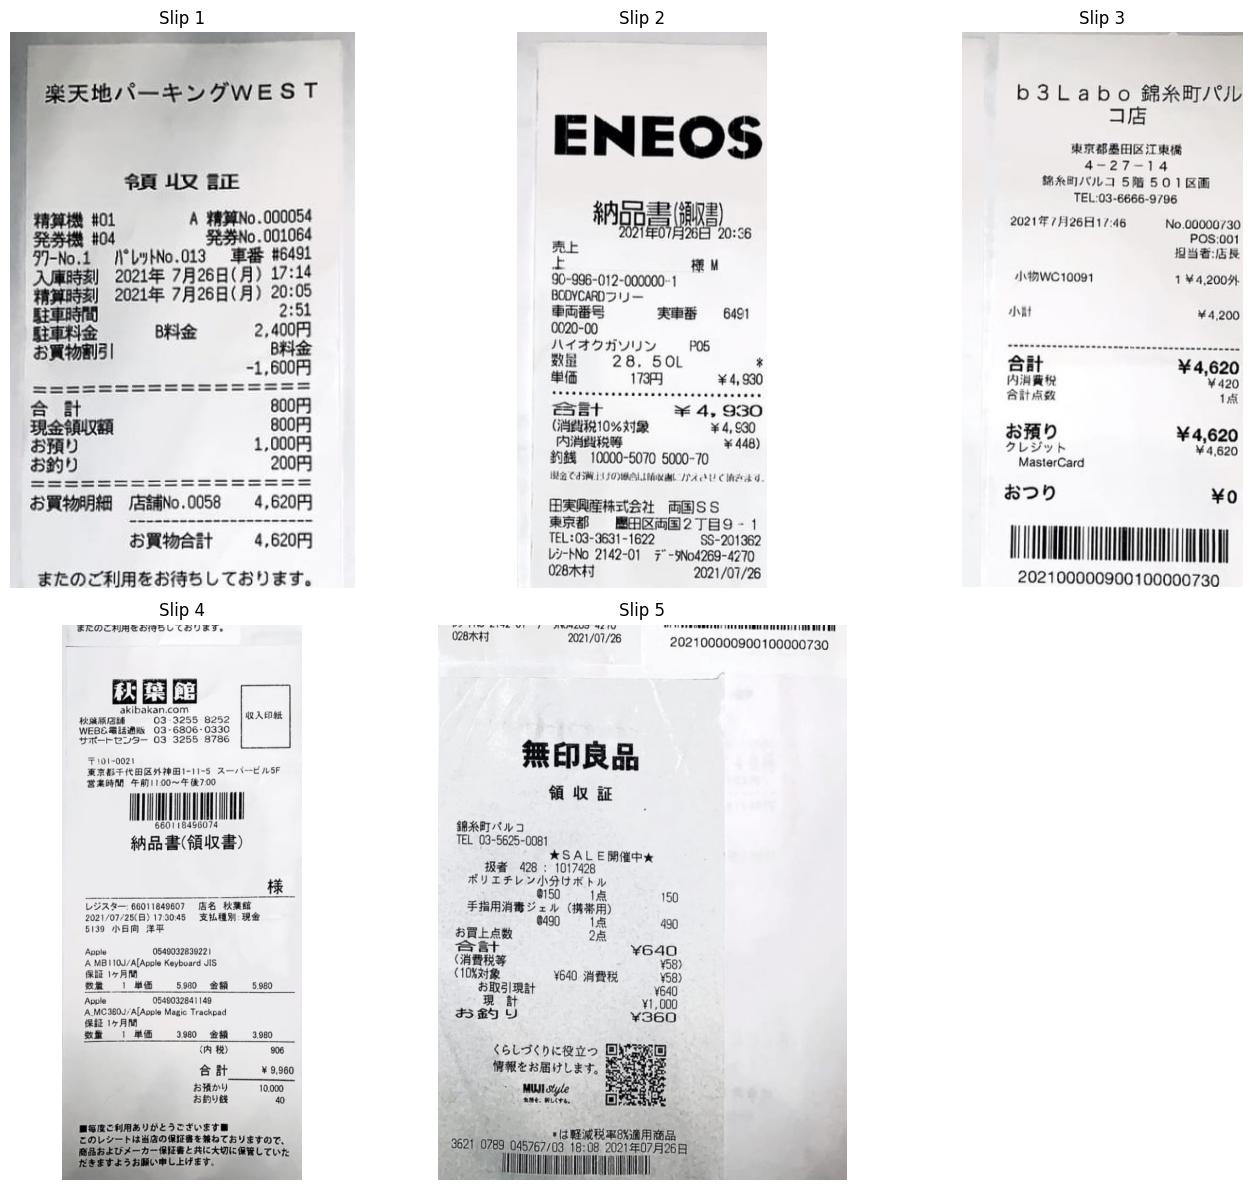

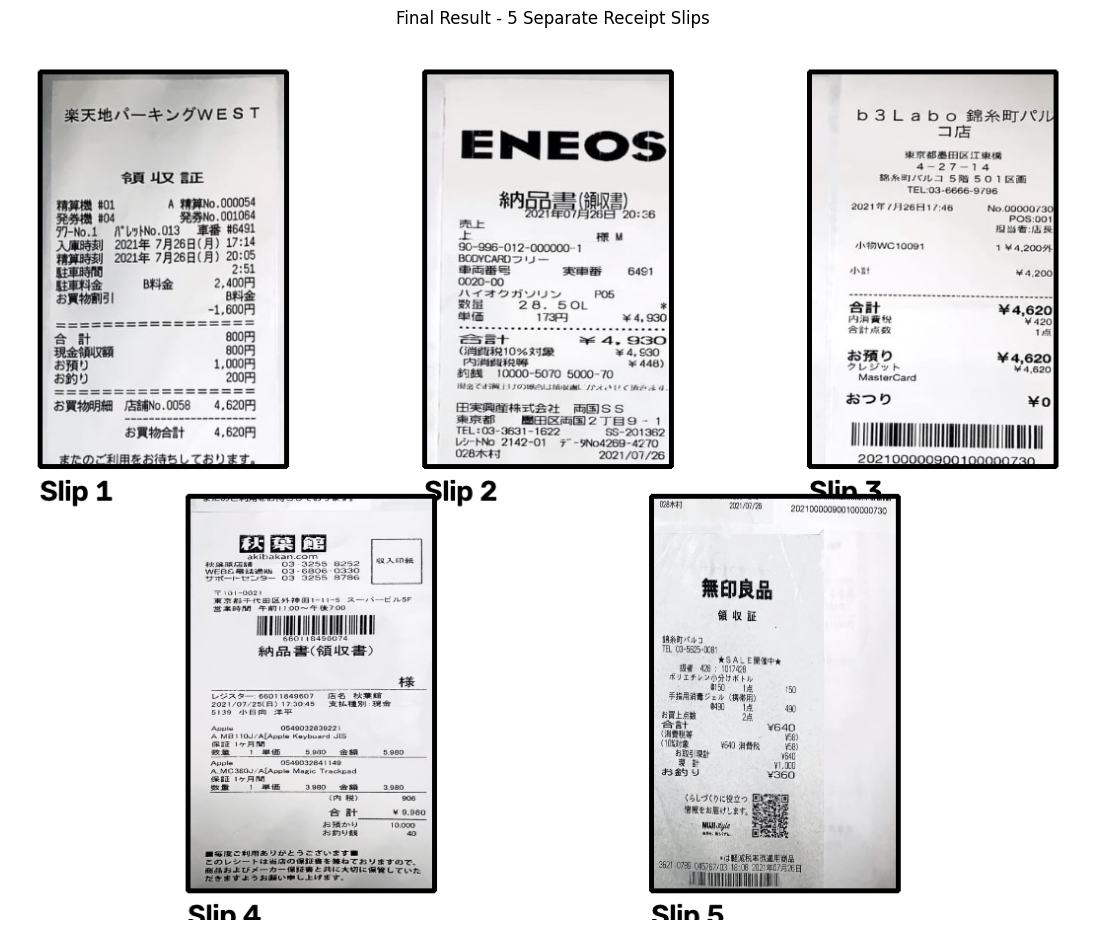


PROCESS COMPLETED SUCCESSFULLY

Generated Files:
1. border_detection_result.jpg
2. separated_slips/slip_1.jpg
3. separated_slips/slip_2.jpg
4. separated_slips/slip_3.jpg
5. separated_slips/slip_4.jpg
6. separated_slips/slip_5.jpg
7. final_5_slips_result.jpg


In [1]:
# ============================================
# 5 RECEIPT / SLIP EXTRACTION PROJECT
# Computer Vision + Deep Learning Preprocessing Concepts
# ============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

# --------------------------------------------
# STEP 1: Upload Image
# --------------------------------------------

uploaded = files.upload()

image_name = list(uploaded.keys())[0]

image = cv2.imread(image_name)

if image is None:
    print("Error: Image could not be loaded.")
else:
    print("Image loaded successfully!")
    print("Image Size:", image.shape)


# --------------------------------------------
# STEP 2: Basic Image Preprocessing
# --------------------------------------------

# Convert BGR to RGB for displaying
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Gaussian Blur
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Edge Detection
edges = cv2.Canny(blur, 50, 150)


# --------------------------------------------
# STEP 3: Define Output Folder
# --------------------------------------------

output_folder = "separated_slips"

if not os.path.exists(output_folder):
    os.makedirs(output_folder)


# --------------------------------------------
# STEP 4: Slip Bounding Boxes
# --------------------------------------------
#
# These coordinates are normalized according to
# the uploaded receipt image.
#
# Format:
# (x1, y1, x2, y2)
#
# 1 = Parking Receipt
# 2 = ENEOS Receipt
# 3 = b3Labo Receipt
# 4 = Akihabara Receipt
# 5 = MUJI Receipt
#
# --------------------------------------------

h, w = image.shape[:2]

slip_boxes = [

    # Slip 1
    (0.015, 0.025, 0.315, 0.365),

    # Slip 2
    (0.405, 0.045, 0.680, 0.475),

    # Slip 3
    (0.680, 0.050, 0.985, 0.475),

    # Slip 4
    (0.015, 0.355, 0.405, 0.990),

    # Slip 5
    (0.420, 0.450, 0.985, 0.990)
]


# --------------------------------------------
# STEP 5: Convert Normalized Coordinates
# --------------------------------------------

boxes = []

for box in slip_boxes:

    x1 = int(box[0] * w)
    y1 = int(box[1] * h)

    x2 = int(box[2] * w)
    y2 = int(box[3] * h)

    boxes.append((x1, y1, x2, y2))


# --------------------------------------------
# STEP 6: Draw Borders on Original Image
# --------------------------------------------

border_image = image.copy()

for i, (x1, y1, x2, y2) in enumerate(boxes):

    # Draw rectangle
    cv2.rectangle(
        border_image,
        (x1, y1),
        (x2, y2),
        (0, 0, 255),
        5
    )

    # Label
    label = "Slip " + str(i + 1)

    cv2.putText(
        border_image,
        label,
        (x1 + 10, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (0, 0, 255),
        3
    )


# --------------------------------------------
# STEP 7: Crop and Save 5 Slips
# --------------------------------------------

slips = []

for i, (x1, y1, x2, y2) in enumerate(boxes):

    # Crop receipt
    slip = image[y1:y2, x1:x2]

    # Save image
    file_name = os.path.join(
        output_folder,
        "slip_" + str(i + 1) + ".jpg"
    )

    cv2.imwrite(file_name, slip)

    slips.append(slip)

    print("Saved:", file_name)


# --------------------------------------------
# STEP 8: Display Original + Borders
# --------------------------------------------

plt.figure(figsize=(12, 16))

plt.imshow(
    cv2.cvtColor(border_image, cv2.COLOR_BGR2RGB)
)

plt.title("Original Image with 5 Detected Slip Borders")

plt.axis("off")

plt.show()


# --------------------------------------------
# STEP 9: Display 5 Separate Slips
# --------------------------------------------

plt.figure(figsize=(14, 12))

for i, slip in enumerate(slips):

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        cv2.cvtColor(slip, cv2.COLOR_BGR2RGB)
    )

    plt.title("Slip " + str(i + 1))

    plt.axis("off")


plt.tight_layout()

plt.show()


# --------------------------------------------
# STEP 10: Create Final Combined Result
# --------------------------------------------

# Resize slips for presentation

display_slips = []

for slip in slips:

    temp = cv2.resize(
        slip,
        (250, 400)
    )

    display_slips.append(temp)


# White canvas

canvas = np.ones(
    (900, 1100, 3),
    dtype=np.uint8
) * 255


# --------------------------------------------
# Put Slip 1, 2, 3
# --------------------------------------------

positions = [

    (30, 40),       # Slip 1
    (420, 40),      # Slip 2
    (810, 40),      # Slip 3
    (180, 470),     # Slip 4
    (650, 470)      # Slip 5
]


for i, slip in enumerate(display_slips):

    x, y = positions[i]

    h2, w2 = slip.shape[:2]

    canvas[
        y:y+h2,
        x:x+w2
    ] = slip

    # Border
    cv2.rectangle(
        canvas,
        (x, y),
        (x+w2, y+h2),
        (0, 0, 0),
        3
    )

    # Label
    cv2.putText(
        canvas,
        "Slip " + str(i+1),
        (x, y+h2+35),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 0),
        2
    )


# --------------------------------------------
# STEP 11: Display Final Result
# --------------------------------------------

plt.figure(figsize=(14, 12))

plt.imshow(
    cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
)

plt.title(
    "Final Result - 5 Separate Receipt Slips"
)

plt.axis("off")

plt.show()


# --------------------------------------------
# STEP 12: Save Final Result
# --------------------------------------------

final_result_path = "final_5_slips_result.jpg"

cv2.imwrite(
    final_result_path,
    canvas
)

border_result_path = "border_detection_result.jpg"

cv2.imwrite(
    border_result_path,
    border_image
)

print("\n===================================")
print("PROCESS COMPLETED SUCCESSFULLY")
print("===================================")

print("\nGenerated Files:")

print("1. border_detection_result.jpg")

for i in range(5):
    print(
        str(i+2) +
        ". separated_slips/slip_" +
        str(i+1) +
        ".jpg"
    )

print("7. final_5_slips_result.jpg")